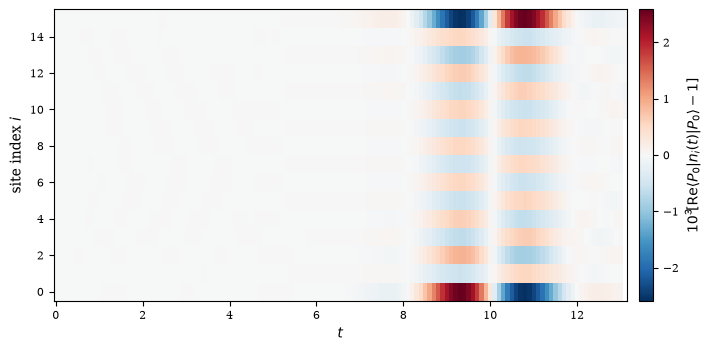

In [ ]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm


file = "/Users/qqt/Library/CloudStorage/OneDrive-OakRidgeNationalLaboratory/Research_Projects/r_stcvsttc/code/template_folder/N=16_Nup=8_Ndown=8_20260928_142304/td_N=16_Nup=8_Ndown=8_20260928_143021/N=16_Nup=8_Ndown=8_20260928_143021_<P0|n|P0>.csv"
df = pd.read_csv(file)

for col in ["t", "site_index", "real_part"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["t", "site_index", "real_part"])
df["site_index"] = df["site_index"].astype(int)

# Deviation from unit filling, shown in 10^-3 units
df["delta_n"] = 1e3 * (df["real_part"] - 1.0)

table = (
    df.pivot(
        index="site_index",
        columns="t",
        values="delta_n"
    )
    .sort_index()
    .sort_index(axis=1)
)

# Symmetric color limits around zero
vmax = np.nanmax(np.abs(table.to_numpy()))
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 9,
    "axes.labelsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

fig, ax = plt.subplots(figsize=(7.0, 3.4), constrained_layout=True)

mesh = ax.pcolormesh(
    table.columns,
    table.index,
    table.to_numpy(),
    shading="nearest",       # no artificial smoothing
    cmap="RdBu_r",
    norm=norm,
    rasterized=True         # keeps the PDF reasonably small
)

ax.set_xlabel(r"$t$")
ax.set_ylabel(r"site index $i$")
ax.set_yticks(np.arange(0, 16, 2))
ax.set_ylim(-0.5, 15.5)

cbar = fig.colorbar(mesh, ax=ax, pad=0.02)
cbar.set_label(
    r"$10^3\!\left[\mathrm{Re}\langle P_0|n_i(t)|P_0\rangle-1\right]$"
)

fig.savefig("occupation_spacetime.pdf", bbox_inches="tight")
fig.savefig("occupation_spacetime.png", dpi=600, bbox_inches="tight")
plt.show()